# 特征表征与 RNN 文本序列预测
## 一、实验目的
1. 深度理解特征空间：通过度量学习 (Metric Learning) 观察 CNN 如何将图像映射 为具有语义凝聚性的向量； 
2. 掌握度量学习思想：理解 Center Loss 在特征聚类中的作用，观察类内紧凑、类间 分离的特征分布； 
3. 理解序列建模任务：通过文本预测实验，理解文本数据中的前后依赖关系； 
4. 掌握 RNN 基本原理：理解循环神经网络如何通过隐藏状态保存历史信息，并用 于字符级文本预测任务； 

## 二、实验环境与数据说明表
| 项目         | 填写内容                                      |
| ------------ | --------------------------------------------- |
| 运行设备     | 个人电脑                                      |
| 硬件环境     | GPU                                           |
| 软件环境     | torch2.12.0+cu126                             |
| 数据集       | MNIST                                         |
| 训练集数量   | 60000                                         |
| 测试集数量   | 10000                                         |
| 数据预处理   | transforms.Normalize((0.1307,), (0.3081,)) |
| ……           | ……                                            |

## 三、实验原理
### 1. LeNet-5 架构复习（CNN 基础）
LeNet 是 CNN 的开山之作，理解其层次结构是复习的关键。 

• 卷积层：通过局部感受野提取边缘与纹理特征。 

• 下采样层：通过 Max Pooling 或 Average Pooling 减少参数量，增加平移不变性。 

• 全连接层：将空间特征展平后进行高阶组合，最终输出类别评分。 

• Batch Normalization：在激活函数前对小批量数据进行归一化，使得输入均值 为 0，方差为 1，极大缓解了对参数初始化的依赖。 

### 2. 度量学习与 Center Loss
传统的 CrossEntropyLoss 只负责“把类分对”，但不保证“类内距离小”。 

• Center Loss 公式： $\begin{array} { r } { L _ { c } = \frac { 1 } { 2 } \sum _ { i = 1 } ^ { m } \left\| x _ { i } - c _ { y _ { i } } \right\| _ { 2 } ^ { 2 } \mathrm { ~ } } \end{array}$ 。它学习每个类别的中心 $c _ { y _ { i } }$ ，并惩罚 样本点 $x _ { i }$ 远离其对应中心的距离。 

• 作用：在分类准确的基础上，显著增强特征的判别性。 

### 3. RNN 序列建模原理
RNN 是处理序列数据的经典模型。它通过隐藏状态在时间步之间传递历史信息。对 于时刻 t，RNN 的基本计算形式为： 
$$
h_{t} = \tanh (W _ {x h} x_{t} + W _ {h h} h_{t - 1} + b_{h})
$$
$$
y_{t} = W_{h y} h_{t} + b_{y}
$$
其中， $x_{ t }$ 表示当前输入， $h_{t}$ 表示当前隐藏状态， $h_{t - 1 }$ 表示上一时刻隐藏状态， $y_{ t }$ 表 示当前输出。 
在文本预测任务中，RNN 可以根据前面已经出现的字符，预测下一个字符。 

### 4. PyTorch 中 nn.RNN 的使用
本实验使用 PyTorch 中封装好的 nn.RNN 构建循环神经网络模型。其基本形式为： 
```python
nn.RNN(input_size, hidden_size, num_layers, batch_first=True) 
```
其中，主要参数含义如下： 

• input_size：表示每个时间步输入向量的维度，通常等于字符嵌入维度 embedding_dim； 

• hidden_size：表示隐藏状态维度，用于控制 RNN 保存历史信息的能力； 

• num_layers：表示 RNN 的层数； 

• batch_first=True：表示输入张量的第一个维度为 batch 维度，此时输入张量形状为： 

```txt
[batch_size, num_steps, input_size] 
```

### 5. 困惑度 Perplexity
困惑度 Perplexity 是语言模型中常用的评价指标，可以反映模型对下一个字符预测的不确定程度。通常可以表示为： 
$$
\mathrm{Perplexity} = e ^ {\mathrm{Loss}}
$$
当模型的 Loss 较小时，Perplexity 也会较低，说明模型对下一个字符的预测更加确定；当 Perplexity 较高时，说明模型预测更加混乱，文本建模效果较差。 

## 四、实验过程与关键代码
### 阶段一：度量学习与特征可视化
#### 1. 轻量化 CNN 构建（复习 + BN 拓展）
任务要求：在经典 LeNet-5 的基础上，在卷积层和全连接层后引入 Batch Normalization。通过实验观察 Batch Normalization 对模型训练过程的影响，包括模型收敛速度、训练稳定性以及测试集分类效果。 

注：
1. 使用 torchvision.datasets.MNIST 加载数据。由于是卷积模型，这次实验中，输入保持为 $1 \times 28 \times 28$ 的张量，无需像实验 1 那样， 将图像展成 784 维的列向量作为 MLP 的输入。
2. 定义类 LeNetPlus，在卷积层 nn.Conv2d 和全连接层后 加上 nn.BatchNorm2d。 


##### （1）环境导入

In [1]:

%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


##### （2）加载 MNIST 数据（保持 1×28×28 张量）

In [2]:
# 数据路径和超参数设置
DATA_ROOT = './mnist_data'
batch_size = 64
if not os.path.exists(DATA_ROOT):
    os.makedirs(DATA_ROOT)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root=DATA_ROOT, train=True,
                                download=True, transform=transform)
test_dataset = datasets.MNIST(root=DATA_ROOT, train=False,
                               download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'训练集: {len(train_dataset)} 样本')
print(f'测试集: {len(test_dataset)} 样本')
print(f'图像形状: {train_dataset[0][0].shape}')

训练集: 60000 样本
测试集: 10000 样本
图像形状: torch.Size([1, 28, 28])


##### （3）基础 LeNet（无 BN，用于对比）

In [3]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_lenet = LeNet().to(device)
print(model_lenet)
print(f'LeNet 参数量: {sum(p.numel() for p in model_lenet.parameters()):,}')

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
LeNet 参数量: 61,706


##### （4）LeNetPlus（添加 BatchNorm）
比较与没有 BN 的 LeNet 收敛速度区别。

In [4]:
class LeNetPlus(nn.Module):
    def __init__(self, feature_dim=2):
        super().__init__()
        self.feature_dim = feature_dim

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(6)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(16)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.bn3 = nn.BatchNorm1d(120)

        self.fc2 = nn.Linear(120, 84)
        self.bn4 = nn.BatchNorm1d(84)

        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.bn3(self.fc1(x)))
        x = F.relu(self.bn4(self.fc2(x)))
        out = self.fc3(x)
        return out

model_plus = LeNetPlus(feature_dim=2).to(device)
print(model_plus)
print(f'LeNetPlus 参数量: {sum(p.numel() for p in model_plus.parameters()):,}')

LeNetPlus(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (bn3): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (bn4): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
LeNetPlus 参数量: 62,158


##### （5）通用训练/评估/可视化工具函数

In [5]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()  # 清空梯度
        output = model(data)  # 前向传播
        loss = criterion(output, target)  # 计算损失
        loss.backward()  # 反向传播
        optimizer.step()  # 更新参数
        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += data.size(0)
    return total_loss / total, 100. * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += data.size(0)
    return total_loss / total, 100. * correct / total

@torch.no_grad()
def get_features(model, loader):
    model.eval()
    features_list, labels_list = [], []
    for data, target in loader:
        data = data.to(device)
        _, feat = model(data, return_feature=True)
        features_list.append(feat.cpu().numpy())  # 特征
        labels_list.append(target.numpy())  # 标签
    return np.concatenate(features_list), np.concatenate(labels_list)

print('工具函数定义完成')

工具函数定义完成


##### （6）训练基础 LeNet（基准对照组）

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lenet.parameters(), lr=0.001)
epochs = 10

lenet_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model_lenet, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model_lenet, test_loader, criterion)
    lenet_history['train_loss'].append(train_loss)
    lenet_history['test_loss'].append(test_loss)
    lenet_history['train_acc'].append(train_acc)
    lenet_history['test_acc'].append(test_acc)
    print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')

print(f'\nLeNet 最终测试准确率: {test_acc:.2f}%')

Epoch  1/10 | Train Loss: 0.2104 Acc: 93.47% | Test Loss: 0.0698 Acc: 97.92%
Epoch  2/10 | Train Loss: 0.0640 Acc: 98.03% | Test Loss: 0.0402 Acc: 98.68%
Epoch  3/10 | Train Loss: 0.0461 Acc: 98.56% | Test Loss: 0.0292 Acc: 99.05%
Epoch  4/10 | Train Loss: 0.0369 Acc: 98.82% | Test Loss: 0.0341 Acc: 98.90%
Epoch  5/10 | Train Loss: 0.0292 Acc: 99.06% | Test Loss: 0.0307 Acc: 99.05%
Epoch  6/10 | Train Loss: 0.0247 Acc: 99.18% | Test Loss: 0.0324 Acc: 98.94%
Epoch  7/10 | Train Loss: 0.0216 Acc: 99.29% | Test Loss: 0.0370 Acc: 98.92%
Epoch  8/10 | Train Loss: 0.0183 Acc: 99.41% | Test Loss: 0.0293 Acc: 99.02%
Epoch  9/10 | Train Loss: 0.0161 Acc: 99.50% | Test Loss: 0.0300 Acc: 99.00%
Epoch 10/10 | Train Loss: 0.0133 Acc: 99.55% | Test Loss: 0.0291 Acc: 99.23%

LeNet 最终测试准确率: 99.23%


##### （7）训练基础 LeNetPlus（实验组）

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_plus.parameters(), lr=0.001)
epochs = 10

plus_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model_plus, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model_plus, test_loader, criterion)
    plus_history['train_loss'].append(train_loss)
    plus_history['test_loss'].append(test_loss)
    plus_history['train_acc'].append(train_acc)
    plus_history['test_acc'].append(test_acc)
    print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')

print(f'\nLeNetPlus 最终测试准确率: {test_acc:.2f}%')

Epoch  1/10 | Train Loss: 0.0499 Acc: 98.47% | Test Loss: 0.0388 Acc: 98.77%
Epoch  2/10 | Train Loss: 0.0323 Acc: 98.97% | Test Loss: 0.0284 Acc: 99.14%
Epoch  3/10 | Train Loss: 0.0261 Acc: 99.16% | Test Loss: 0.0287 Acc: 99.20%
Epoch  4/10 | Train Loss: 0.0216 Acc: 99.31% | Test Loss: 0.0246 Acc: 99.20%
Epoch  5/10 | Train Loss: 0.0180 Acc: 99.43% | Test Loss: 0.0303 Acc: 99.07%
Epoch  6/10 | Train Loss: 0.0163 Acc: 99.46% | Test Loss: 0.0307 Acc: 99.05%
Epoch  7/10 | Train Loss: 0.0135 Acc: 99.56% | Test Loss: 0.0305 Acc: 99.11%
Epoch  8/10 | Train Loss: 0.0122 Acc: 99.56% | Test Loss: 0.0290 Acc: 99.12%
Epoch  9/10 | Train Loss: 0.0114 Acc: 99.64% | Test Loss: 0.0264 Acc: 99.23%
Epoch 10/10 | Train Loss: 0.0095 Acc: 99.67% | Test Loss: 0.0316 Acc: 99.08%

LeNetPlus 最终测试准确率: 99.08%


##### （8）LeNet vs LeNetPlus+CenterLoss：Loss 和准确率对比


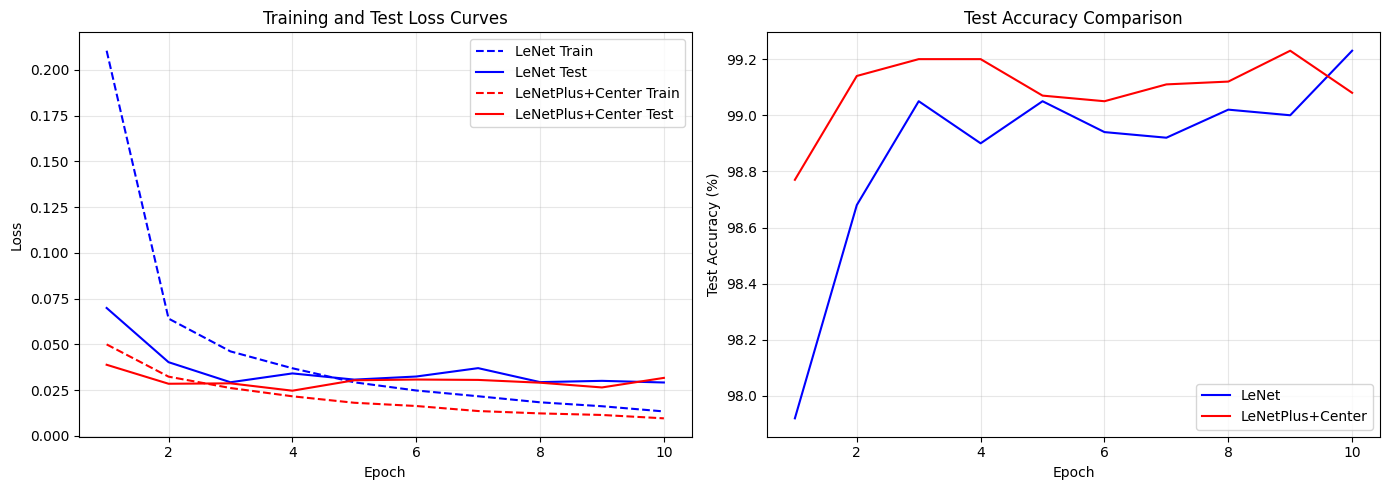

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, len(lenet_history['train_loss'])+1), lenet_history['train_loss'], 'b--', label='LeNet Train')
ax.plot(range(1, len(lenet_history['train_loss'])+1), lenet_history['test_loss'], 'b-', label='LeNet Test')
ax.plot(range(1, len(plus_history['train_loss'])+1), plus_history['train_loss'], 'r--', label='LeNetPlus+Center Train')
ax.plot(range(1, len(plus_history['train_loss'])+1), plus_history['test_loss'], 'r-', label='LeNetPlus+Center Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Test Loss Curves')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(lenet_history['test_acc'])+1), lenet_history['test_acc'], 'b-', label='LeNet')
ax.plot(range(1, len(plus_history['test_acc'])+1), plus_history['test_acc'], 'r-', label='LeNetPlus+Center')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. Center Loss 实现与聚类分析
任务要求：编写自定义 Center Loss 模块，为每个类别维护一个特征中心。训练目标为： 
$$
L = L _ {\mathrm{softmax}} + \lambda L _ {\mathrm{center}}
$$
其中， $L _ { \mathrm { softmax } }$ 用于分类， $L _ { \mathrm { { c e n t e r } } }$ 用于约束同类样本在特征空间中的距离。 

进阶要求：将网络最后一层特征维度设置为 2，并使用 matplotlib 绘制二维特征散点图，观察不同类别样本从混乱分布到“类内紧凑、类间分离”的变化过程。 

注：
1. 注意 CenterLoss 的参数（各类的中心）也需要在训练过程中更新，通常使用 optim.SGD 专门为一个独立的参数组进行更新。
2. 特征可视化：在 LeNet + Center Loss 训练过程中，每隔 5 个 Epoch 使用模型输出的 2D 特征绘制散点图性能分折。 

##### （1）Center Loss 模块

In [10]:
class CenterLoss(nn.Module):
    def __init__(self, num_classes, feat_dim):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim) * 0.01)

    def forward(self, features, labels):
        batch_size = features.size(0)
        centers_batch = self.centers[labels]
        loss = F.mse_loss(features, centers_batch, reduction='sum') / batch_size
        return loss

center_loss_fn = CenterLoss(num_classes=10, feat_dim=2).to(device)
print('CenterLoss 初始化完成')
print(f'初始中心: \n{center_loss_fn.centers.data}')

CenterLoss 初始化完成
初始中心: 
tensor([[ 0.0078, -0.0029],
        [-0.0041,  0.0073],
        [ 0.0076,  0.0001],
        [ 0.0045,  0.0041],
        [-0.0056, -0.0021],
        [ 0.0020, -0.0012],
        [-0.0020, -0.0076],
        [ 0.0033, -0.0184],
        [ 0.0036,  0.0196],
        [ 0.0116,  0.0005]], device='cuda:0')


##### （4）LeNetPlus+CenterLoss（最后输出 2D 特征用于可视化）

说明：在卷积层和全连接层后加入 BatchNorm，将最后一层特征维度设为 2 以便绘制散点图。\
注意：最终分类需要一个独立的 Linear 层把 2D 特征映射到 10 类。

In [12]:
class LeNetPlusCenterLoss(nn.Module):
    def __init__(self, feature_dim=2):
        super().__init__()
        self.feature_dim = feature_dim

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(6)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(16)

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.bn3 = nn.BatchNorm1d(120)

        self.fc2 = nn.Linear(120, 84)
        self.bn4 = nn.BatchNorm1d(84)

        self.fc3 = nn.Linear(84, feature_dim)

        self.classifier = nn.Linear(feature_dim, 10)

    def forward(self, x, return_feature=False):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.bn3(self.fc1(x)))
        x = F.relu(self.bn4(self.fc2(x)))
        feature = self.fc3(x)
        out = self.classifier(feature)
        if return_feature:
            return out, feature
        return out

model_plus_center_loss = LeNetPlusCenterLoss(feature_dim=2).to(device)
print(model_plus_center_loss)
print(f'LeNetPlusCenterLoss 参数量: {sum(p.numel() for p in model_plus_center_loss.parameters()):,}')

LeNetPlusCenterLoss(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (bn3): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (bn4): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
  (classifier): Linear(in_features=2, out_features=10, bias=True)
)
LeNetPlusCenterLoss 参数量: 61,508


##### （2）训练 LeNetPlus + Center Loss + 每5轮可视化

注意：CenterLoss 的中心参数需要用 SGD 单独更新（使用分组优化器）。

In [ ]:
lambda_center = 0.1
criterion_ce = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_plus_center_loss.parameters(), lr=0.001)
center_optimizer = torch.optim.SGD(center_loss_fn.parameters(), lr=0.5)

epochs = 20
plus_history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
snapshots = []

for epoch in range(epochs):
    model_plus_center_loss.train()
    center_loss_fn.train()
    epoch_loss = 0
    correct, total = 0, 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        center_optimizer.zero_grad()

        output, features = model_plus_center_loss(data, return_feature=True)

        loss_ce = criterion_ce(output, target)
        loss_center = center_loss_fn(features, target)
        loss = loss_ce + lambda_center * loss_center

        loss.backward()
        optimizer.step()
        center_optimizer.step()

        epoch_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += data.size(0)

    train_loss = epoch_loss / total
    train_acc = 100. * correct / total

    test_loss, test_acc = evaluate(model_plus_center_loss, test_loader, criterion_ce)

    plus_history['train_loss'].append(train_loss)
    plus_history['test_loss'].append(test_loss)
    plus_history['train_acc'].append(train_acc)
    plus_history['test_acc'].append(test_acc)

    print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        features_2d, labels_2d = get_features(model_plus_center_loss, test_loader)
        snapshots.append((epoch + 1, features_2d, labels_2d))

print('\nLeNetPlus + CenterLoss 训练完成')

Epoch  1/20 | Train Loss: 1.1551 Acc: 73.76% | Test Loss: 0.6051 Acc: 96.19%
Epoch  2/20 | Train Loss: 0.5983 Acc: 96.07% | Test Loss: 0.3438 Acc: 97.21%
Epoch  3/20 | Train Loss: 0.4116 Acc: 97.20% | Test Loss: 0.2185 Acc: 98.17%
Epoch  4/20 | Train Loss: 0.3174 Acc: 97.83% | Test Loss: 0.1810 Acc: 98.15%
Epoch  5/20 | Train Loss: 0.2531 Acc: 98.14% | Test Loss: 0.1459 Acc: 98.30%
Epoch  6/20 | Train Loss: 0.2082 Acc: 98.42% | Test Loss: 0.1271 Acc: 98.32%
Epoch  7/20 | Train Loss: 0.1731 Acc: 98.66% | Test Loss: 0.1139 Acc: 98.42%
Epoch  8/20 | Train Loss: 0.1493 Acc: 98.78% | Test Loss: 0.1074 Acc: 98.37%
Epoch  9/20 | Train Loss: 0.1286 Acc: 98.93% | Test Loss: 0.0985 Acc: 98.45%
Epoch 10/20 | Train Loss: 0.1149 Acc: 98.99% | Test Loss: 0.0934 Acc: 98.54%
Epoch 11/20 | Train Loss: 0.0948 Acc: 99.17% | Test Loss: 0.0876 Acc: 98.60%
Epoch 12/20 | Train Loss: 0.0862 Acc: 99.25% | Test Loss: 0.0881 Acc: 98.52%
Epoch 13/20 | Train Loss: 0.0798 Acc: 99.29% | Test Loss: 0.0831 Acc: 98.63%

##### （4）2D 特征空间可视化（每隔 5 个 Epoch 的快照）

观察不同类别样本从混乱分布到“类内紧凑、类间分离”的变化过程。

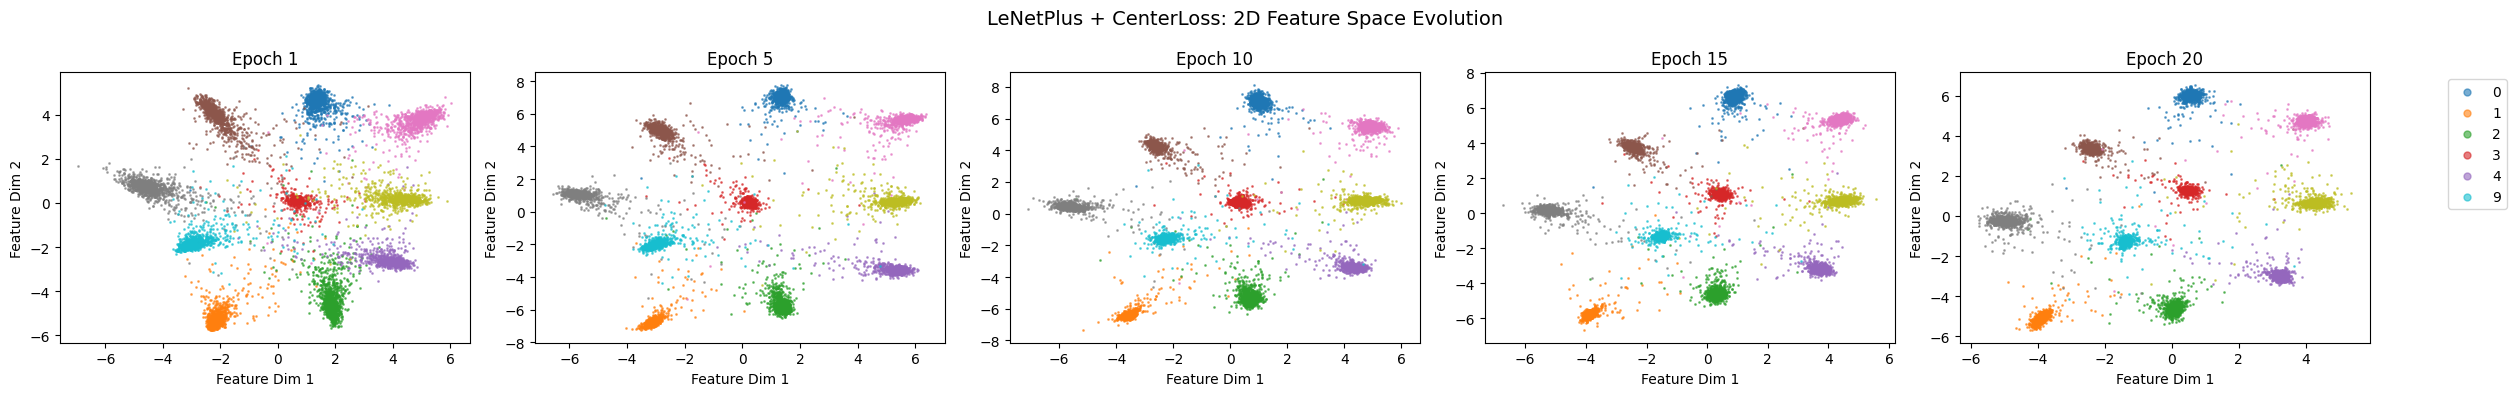

In [11]:
n = len(snapshots)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (ep, feat, lbl) in zip(axes, snapshots):
    for c in range(10):
        mask = lbl == c
        ax.scatter(feat[mask, 0], feat[mask, 1], c=[colors[c]], s=1,
                   alpha=0.6, label=str(c) if c < 5 or c == 9 else '')
    ax.set_title(f'Epoch {ep}')
    ax.set_xlabel('Feature Dim 1')
    ax.set_ylabel('Feature Dim 2')

plt.suptitle('LeNetPlus + CenterLoss: 2D Feature Space Evolution', fontsize=14)
plt.legend(markerscale=5, loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.show()

### 3. 扩展任务（选做）
1. 高级聚类可视化：尝试使用 T-SNE 或 UMAP 对全连接层输出的高维特征进行降维，并与直接设置二维特征输出的可视化结果进行比较。 
观察不同方法下类别之间的聚类边界、类内紧凑程度以及可视化效果差异。

高级可视化对比：使用 12000 个训练样本、2000 个测试样本，保证 2D 与高维模型在同一数据子集上训练。

[1/2] 训练直接输出 2D 特征的模型
Epoch  1/8 | Train Loss: 2.0523 Acc: 34.80% | Test Loss: 1.7903 Acc: 38.85%
Epoch  2/8 | Train Loss: 1.8039 Acc: 39.19% | Test Loss: 1.5816 Acc: 40.50%
Epoch  3/8 | Train Loss: 1.6196 Acc: 42.91% | Test Loss: 1.4519 Acc: 43.90%
Epoch  4/8 | Train Loss: 1.4725 Acc: 45.83% | Test Loss: 1.3374 Acc: 45.50%
Epoch  5/8 | Train Loss: 1.3579 Acc: 50.38% | Test Loss: 1.2515 Acc: 52.75%
Epoch  6/8 | Train Loss: 1.2616 Acc: 56.92% | Test Loss: 1.1744 Acc: 57.25%
Epoch  7/8 | Train Loss: 1.1814 Acc: 62.40% | Test Loss: 1.1093 Acc: 59.40%
Epoch  8/8 | Train Loss: 1.1070 Acc: 66.06% | Test Loss: 1.0403 Acc: 66.25%

[2/2] 训练高维特征模型
Epoch  1/8 | Train Loss: 1.8869 Acc: 80.02% | Test Loss: 1.0377 Acc: 93.05%
Epoch  2/8 | Train Loss: 1.0974 Acc: 95.68% | Test Loss: 0.5653 Acc: 96.60%
Epoch  3/8 | Train Loss: 0.6435 Acc: 97.59% | Test Loss: 0.3414 Acc: 97.50%
Epoch  4/8 | Train Loss: 0.3992 Acc: 98.55% | Test Loss: 0.2236 Acc:

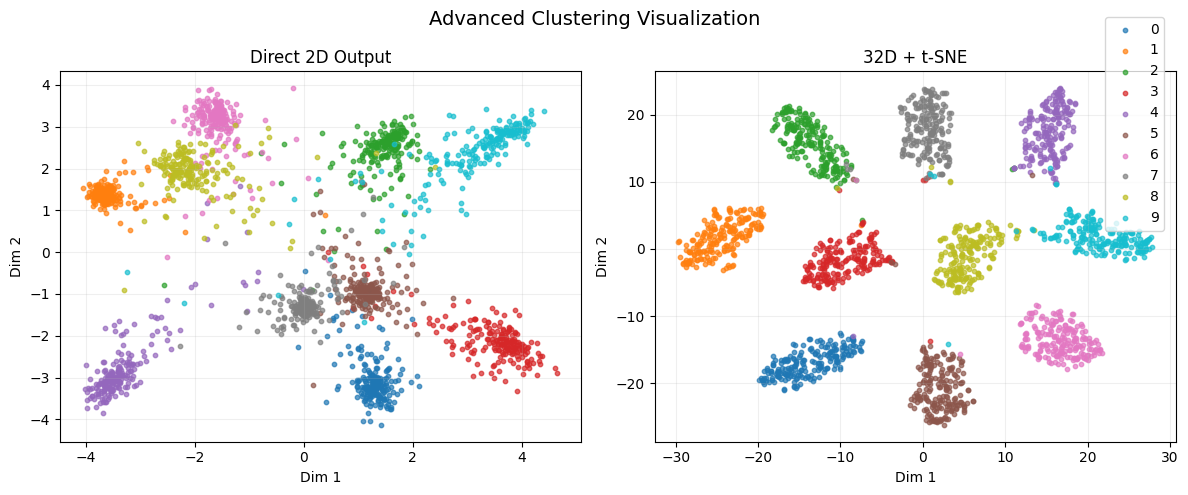


聚类质量指标对比：
          name |  Acc(%) |     类内半径 |      最小类间距 |      分离比 |     全局扩张 |     阶段
-------------------------------------------------------------------------------
Direct 2D Output |   66.25 |   0.5625 |     1.1718 |   8.0339 |   2.3723 |      -
   32D + t-SNE |   98.65 |   3.5962 |    13.6994 |   7.6012 |  14.1105 |      -

结论提示：类内最紧凑的是“Direct 2D Output”，类别边界最清晰的是“32D + t-SNE”，综合分离比最高的是“Direct 2D Output”。
UMAP 当前不可用，已自动跳过：No module named 'umap'


In [14]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path('exp10') if Path('exp10').exists() else Path('.')
if str(NOTEBOOK_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))

from metric_learning_extensions import run_advanced_feature_visualization

lambda_center = 0.1
# If umap-learn is unavailable, the helper will fall back to t-SNE only.
advanced_vis_results = run_advanced_feature_visualization(
    model_cls=LeNetPlusCenterLoss,
    center_loss_cls=CenterLoss,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    device=device,
    lambda_center=lambda_center,
    highdim_feature_dim=32,
    epochs=4 if device.type == 'cpu' else 8,
    train_samples=4000 if device.type == 'cpu' else 12000,
    test_samples=1000 if device.type == 'cpu' else 2000,
    batch_size=256,
    seed=42,
)


聚类质量指标对比：

| name | Acc(%) | 类内半径 | 最小类间距 | 分离比 | 全局扩张 | 阶段|
|------|----------|------------|-----------|-------|----------------|-------------|
|Direct 2D Output |   66.25 |   0.5625 |     1.1718 |   8.0339 |   2.3723 |      -|
|   32D + t-SNE |   98.65 |   3.5962 |    13.6994 |   7.6012 |  14.1105 |      -|

类内最紧凑的是“Direct 2D Output”，类别边界最清晰的是“32D + t-SNE”，综合分离比最高的是“Direct 2D Output”。


2. Center Loss 权重调优：改变 CenterLoss 的权重 λ，记录并分析特征空间从“扩散”到“过坍缩”的临界点。 

λ 扫描：使用 12000 个训练样本、2000 个测试样本，固定 2D 特征维度。

===== 开始训练 λ = 0 =====
Epoch  1/8 | Train Loss: 1.5751 Acc: 44.36% | Test Loss: 1.2053 Acc: 52.35%
Epoch  2/8 | Train Loss: 1.1124 Acc: 54.28% | Test Loss: 0.9927 Acc: 63.20%
Epoch  3/8 | Train Loss: 0.9002 Acc: 67.22% | Test Loss: 0.8268 Acc: 70.70%
Epoch  4/8 | Train Loss: 0.7516 Acc: 73.03% | Test Loss: 0.7095 Acc: 74.85%
Epoch  5/8 | Train Loss: 0.6445 Acc: 76.09% | Test Loss: 0.6264 Acc: 76.65%
Epoch  6/8 | Train Loss: 0.5675 Acc: 78.13% | Test Loss: 0.5679 Acc: 77.40%
Epoch  7/8 | Train Loss: 0.5115 Acc: 78.73% | Test Loss: 0.5377 Acc: 78.00%
Epoch  8/8 | Train Loss: 0.4659 Acc: 79.17% | Test Loss: 0.4973 Acc: 77.35%

===== 开始训练 λ = 0.01 =====
Epoch  1/8 | Train Loss: 1.7094 Acc: 34.41% | Test Loss: 1.3422 Acc: 43.15%
Epoch  2/8 | Train Loss: 1.3936 Acc: 51.44% | Test Loss: 1.1962 Acc: 58.35%
Epoch  3/8 | Train Loss: 1.2682 Acc: 60.09% | Test Loss: 1.0661 Acc: 61.70%
Epoch  4/8 | Train Loss: 1.1766 Acc: 63.08% | Test Loss: 1.0243 Acc: 6

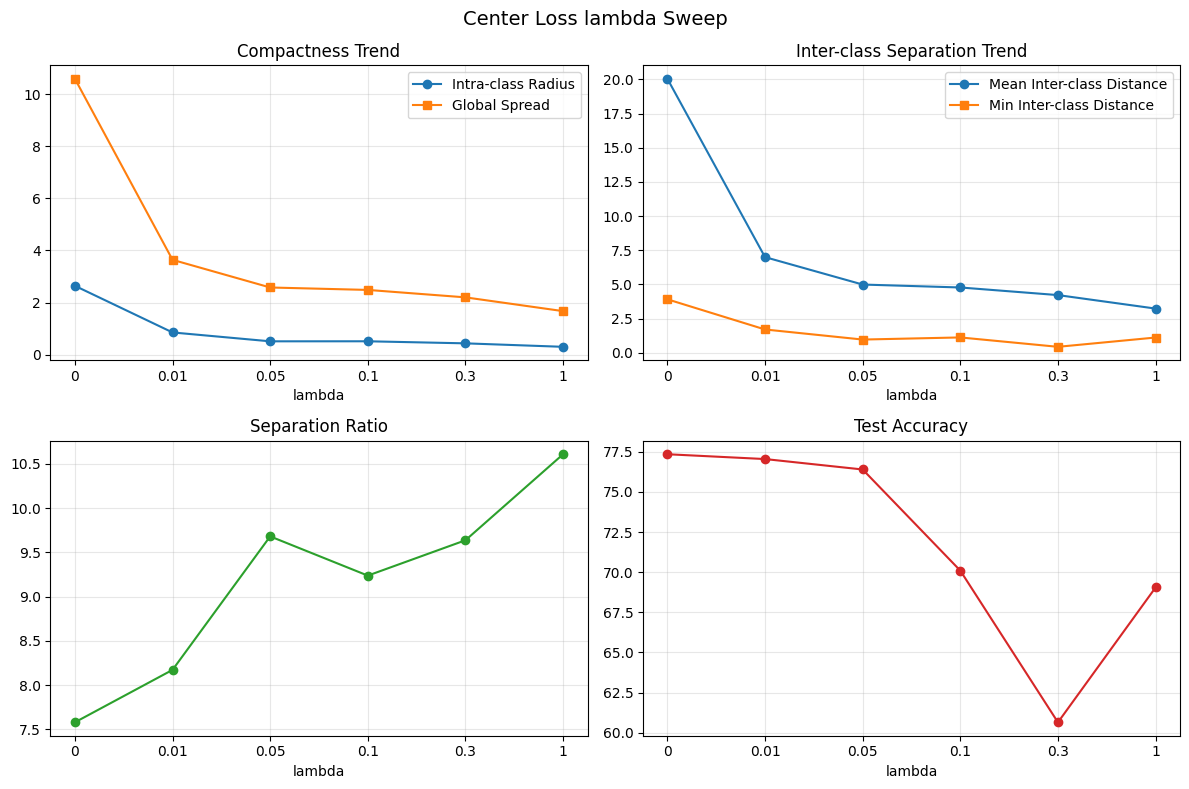

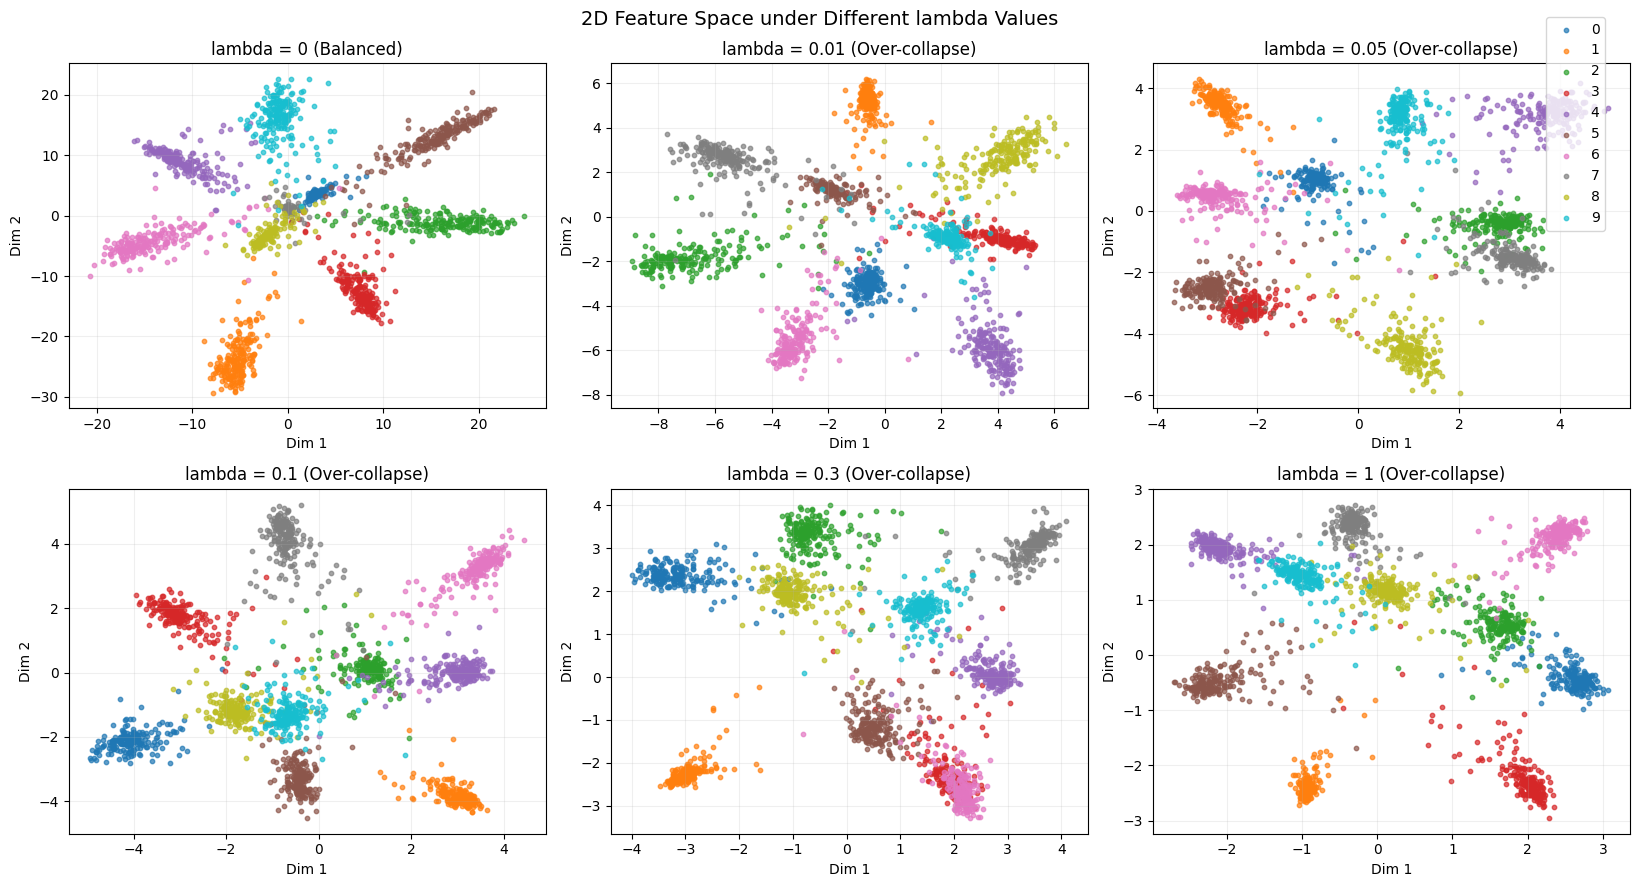


λ 扫描结果汇总：
        lambda |  Acc(%) |     类内半径 |      最小类间距 |      分离比 |     全局扩张 |     阶段
-------------------------------------------------------------------------------
           0.0 |   77.35 |   2.6444 |     3.9067 |   7.5801 |  10.5880 |     平衡
          0.01 |   77.05 |   0.8557 |     1.6992 |   8.1722 |   3.6413 |    过坍缩
          0.05 |   76.40 |   0.5152 |     0.9619 |   9.6796 |   2.5801 |    过坍缩
           0.1 |   70.10 |   0.5167 |     1.1171 |   9.2368 |   2.4869 |    过坍缩
           0.3 |   60.65 |   0.4375 |     0.4307 |   9.6359 |   2.2016 |    过坍缩
           1.0 |   69.05 |   0.3043 |     1.1112 |  10.6073 |   1.6732 |    过坍缩

本次扫描中，λ≈0 附近开始进入较理想的聚类状态，当 λ≈0.01 时开始出现“过坍缩”信号：类内半径继续缩小，但全局扩张和最小类间距开始一起变小。


In [17]:
from metric_learning_extensions import run_lambda_sweep

lambda_sweep_results = run_lambda_sweep(
    model_cls=LeNetPlusCenterLoss,
    center_loss_cls=CenterLoss,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    device=device,
    lambda_values=[0.0, 0.01, 0.05, 0.1, 0.3, 1.0],
    epochs=4 if device.type == 'cpu' else 8,
    train_samples=4000 if device.type == 'cpu' else 12000,
    test_samples=1000 if device.type == 'cpu' else 2000,
    batch_size=256,
    seed=123,
)


### 4. 阶段一结果分析
请对结果进行解读分析。特别是 LeNet 以及 Center Loss 需要观察类内方差（簇的半径）的缩小情况，以及不同类别之间是否更加分离。

**问题：**
1. **Batch Normalization 的效果**：对比 LeNet（无 BN）和 LeNetPlus（有 BN）的训练曲线，BN 明显加速了收敛过程，但在 BN+CenterLoss 模型的训练中，由于最后有了2维空间的瓶颈层，使得训练难度增加，导致训练速度变慢。

2. **Center Loss 的聚类效果**：观察 2D 特征散点图从 Epoch 1 到 Epoch 20 的变化：
   - 最初各数字类别特征混杂在一起
   - 随着训练进行，同类别特征逐渐聚集（类内紧凑）
   - 不同类别之间逐渐拉开距离（类间分离）


**实验总结表格：**

| 实验配置 | 测试准确率 | 特征聚类效果(定性) | 收敛速度 |
|---------|----------|------------------|--------|
| LeNet(基础版) | 99.23% | N/A | 中 |
| LeNet+BN | 99.23% | N/A | 快 |
| LeNet+BN+CenterLoss($\lambda=0.1$) | 98.77% | 簇内部集中，但簇间没有明确的距离，过于分散 | 慢 |

### 阶段二：基于 RNN 的文本序列预测
#### 1. 文本数据集构建
任务要求：使用英文小说 The Time Machine 作为实验数据集，完成字符级文本预 测任务的数据准备。在完成字符编号后，使用滑动窗口方法构造输入序列和目标序列。 例如，若输入序列为： 
$$
time \quad machin
$$ 
则目标序列为：
$$ 
ime \quad machine 
$$
也就是说，目标序列相当于输入序列整体向后移动一个字符。模型需要学习根据当前字符和历史字符预测下一个字符。

文本序列预测部分使用英文小说 The Time Machine 作为数据集。实验中可通过 requests 库从网络下载文本数据，下载地址为：[https://www.gutenberg.org/files/35/35-0.txt]。也可提前下载文本文件并从本地读取。读取文本后，需要完 成文本清洗、字符表构建、字符编号映射和数字序列转换，为后续 RNN 文本预测 模型训练做准备。 

##### （1） 环境导入

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import re
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


##### （2）下载并读取文本数据

In [4]:
url = 'https://www.gutenberg.org/files/35/35-0.txt'
filename = 'timemachine.txt'

if not os.path.exists(filename):
    try:
        import requests
        response = requests.get(url, timeout=30)
        response.encoding = 'utf-8'
        with open(filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
        print('文本下载成功')
    except Exception as e:
        print(f'下载失败: {e}')
        print('请手动下载文本文件到当前目录: {url}')
else:
    print('文本文件已存在')

with open(filename, 'r', encoding='utf-8') as f:
    raw_text = f.read()

print(f'原始文本总字符数: {len(raw_text)}')
print('前500字符预览:')
print(raw_text[:500])

文本文件已存在
原始文本总字符数: 182973
前500字符预览:
*** START OF THE PROJECT GUTENBERG EBOOK 35 ***









The Time Machine



An Invention



by H. G. Wells





CONTENTS



 I Introduction

 II The Machine

 III The Time Traveller Returns

 IV Time Travelling

 V In the Golden Age

 VI The Sunset of Mankind

 VII A Sudden Shock

 VIII Explanation

 IX The Morlocks

 X When Night Came

 XI The Palace of Green Porcelain

 XII In the Darkness

 XIII The Trap of the White Sphinx

 XIV The Further Vision

 XV The Time Traveller’s Return

 XVI Afte


##### （3）文本清洗

In [5]:
def clean_text(text):
    start_marker = '*** START OF THE PROJECT GUTENBERG EBOOK'
    end_marker = '*** END OF THE PROJECT GUTENBERG EBOOK'

    start_idx = text.find(start_marker)
    if start_idx != -1:
        start_idx = text.find('\n', start_idx) + 1
        text = text[start_idx:]

    end_idx = text.find(end_marker)
    if end_idx != -1:
        text = text[:end_idx]

    text = text.lower()

    text = re.sub(r'[^\x20-\x7e\n]', ' ', text)

    text = re.sub(r' +', ' ', text)

    return text

text = clean_text(raw_text)
print(f'清洗后文本长度: {len(text)}')
print('清洗后前500字符:')
print(text[:500])

清洗后文本长度: 182629
清洗后前500字符:









the time machine



an invention



by h. g. wells





contents



 i introduction

 ii the machine

 iii the time traveller returns

 iv time travelling

 v in the golden age

 vi the sunset of mankind

 vii a sudden shock

 viii explanation

 ix the morlocks

 x when night came

 xi the palace of green porcelain

 xii in the darkness

 xiii the trap of the white sphinx

 xiv the further vision

 xv the time traveller s return

 xvi after the story

 epilogue









 i.

 introducti


##### （4）构建字符表与映射


In [51]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f'字符表大小: {vocab_size}')
print(f'字符表: {repr("".join(chars))}')

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

字符表大小: 40
字符表: '\n !(),-.:;?[]_abcdefghijklmnopqrstuvwxyz'


##### （5）滑动窗口构造输入序列与目标序列


In [34]:
seq_length = 80
stride = 5

text_indices = [char_to_idx[ch] for ch in text]

inputs_data = []
targets_data = []
for i in range(0, len(text_indices) - seq_length, stride):  # 跳着选训练集，不容易过拟合
    inputs_data.append(text_indices[i:i + seq_length])
    targets_data.append(text_indices[i + 1:i + seq_length + 1])

inputs_data = torch.tensor(inputs_data, dtype=torch.long)
targets_data = torch.tensor(targets_data, dtype=torch.long)

print(f'输入张量形状: {inputs_data.shape}')
print(f'目标张量形状: {targets_data.shape}')

total = len(inputs_data)
split_idx = int(total * 0.8)
train_inputs, test_inputs = inputs_data[:split_idx], inputs_data[split_idx:]
train_targets, test_targets = targets_data[:split_idx], targets_data[split_idx:]

print(f'训练样本数: {len(train_inputs)}')
print(f'测试样本数: {len(test_inputs)}')

sample_idx = 0
print(f'\n示例: 输入序列前50字符: {"".join(idx_to_char[i.item()] for i in train_inputs[sample_idx][:50])}')
print(f'示例: 目标序列前50字符: {"".join(idx_to_char[i.item()] for i in train_targets[sample_idx][:50])}')

输入张量形状: torch.Size([36510, 80])
目标张量形状: torch.Size([36510, 80])
训练样本数: 29208
测试样本数: 7302

示例: 输入序列前50字符: 








the time machine



an invention



by h.
示例: 目标序列前50字符: 







the time machine



an invention



by h. 


##### （6）数据集类与 DataLoader


In [46]:
class TextDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

batch_size = 128
train_dataset = TextDataset(train_inputs, train_targets)
test_dataset = TextDataset(test_inputs, test_targets)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'训练 DataLoader 批次数: {len(train_loader)}')
print(f'测试 DataLoader 批次数: {len(test_loader)}')

训练 DataLoader 批次数: 229
测试 DataLoader 批次数: 58


#### 2. RNN 模型训练与文本生成
任务要求：构建一个字符级 RNN 文本预测模型，完成模型训练、损失曲线绘制和 文本生成实验。利用 RNN 的 Pytorch 里内置的 nn.RNN 函数完成。 

定义 RNN 文本预测模型 RNNTextModel。模型整体结构为： 
$$
字符编号输入 \rightarrow Embedding 层 \rightarrow RNN 层 \rightarrow Linear 输出层 \rightarrow 字符预测结果 
$$
其中，Embedding 层用于将离散字符编号转换为连续向量，RNN 层用于提取文本 序列中的上下文信息，Linear 层用于将隐藏状态映射到字符表大小的输出空间。 

训练时使用交叉熵损失函数，将每个时间步的输出看作一次字符分类任务。

训练完成后，记录训练集 Loss、测试集 Loss，并绘制 Loss 曲线。同时计算模型的 Perplexity， 用于评价文本预测效果。 

在文本生成阶段，给定一个英文前缀，例如： 
$$
 time \quad traveller 
$$

使用训练好的 RNN 模型继续生成若干字符，观察生成文本是否具有基本英文结构，是否出现局部合理的单词或短语，以及是否存在大量重复字符或乱码现象。 

注：
1. Loss 曲线：记录 RNN 模型在训练集和测试集上的 Loss，并绘制 Loss 曲线； 
2. Perplexity 分析：根据测试集 Loss 计算 Perplexity，观察模型对下一个字符 预测的不确定程度； 
3. 文本生成测试：在 RNN 训练完成后，给定英文前缀，例如 time traveller， 观察模型生成文本的效果；


##### （7）定义 RNN 文本预测模型


In [25]:
class RNNTextModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.drop = nn.Dropout(dropout)  # 防止过拟合
        self.rnn = nn.RNN(embed_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(self.drop(out))
        return out, hidden

model = RNNTextModel(vocab_size).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {total_params:,}')

RNNTextModel(
  (embed): Embedding(40, 128)
  (drop): Dropout(p=0.3, inplace=False)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True)
  (fc): Linear(in_features=256, out_features=40, bias=True)
)
总参数量: 245,800


##### （8）训练与评估函数


In [26]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs.view(-1, vocab_size), targets.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 防止梯度爆炸
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs, _ = model(inputs)
        loss = criterion(outputs.view(-1, vocab_size), targets.view(-1))
        total_loss += loss.item() * inputs.size(0)
    return total_loss / len(loader.dataset)

##### （9）训练模型并记录 Loss


In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 20
train_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    test_loss = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{epochs}')
        print(f'  Train Loss: {train_loss:.4f}')
        print(f'  Test Loss:  {test_loss:.4f}')
        print(f'  Perplexity: {np.exp(test_loss):.2f}')
        print('---')

Epoch  1/20
  Train Loss: 1.9618
  Test Loss:  1.6367
  Perplexity: 5.14
---
Epoch  5/20
  Train Loss: 1.1604
  Test Loss:  1.5972
  Perplexity: 4.94
---
Epoch 10/20
  Train Loss: 0.7943
  Test Loss:  2.0140
  Perplexity: 7.49
---
Epoch 15/20
  Train Loss: 0.6601
  Test Loss:  2.2422
  Perplexity: 9.41
---
Epoch 20/20
  Train Loss: 0.6037
  Test Loss:  2.3635
  Perplexity: 10.63
---


##### （10）绘制 Loss 曲线


In [64]:
def plot_loss(epochs, train_losses, test_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs + 1), train_losses, 'b-', label='Train Loss', linewidth=2)
    plt.plot(range(1, epochs + 1), test_losses, 'r-', label='Test Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Curves')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'最终 Train Loss: {train_losses[-1]:.4f}')
    print(f'最终 Test Loss:  {test_losses[-1]:.4f}')

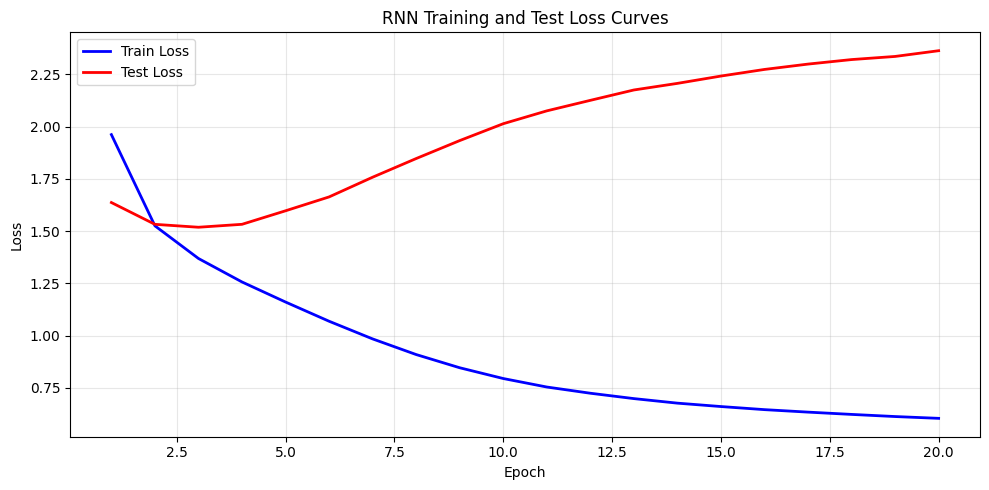

最终 Train Loss: 0.6037
最终 Test Loss:  2.3635


In [29]:
plot_loss(epochs, train_losses, test_losses)

RNN表现出明显的过拟合

##### （11）计算 Perplexity（困惑度）


In [31]:
final_test_loss = evaluate(model, test_loader, criterion)
perplexity = np.exp(final_test_loss)
print(f'Test Loss: {final_test_loss:.4f}')
print(f'Perplexity (困惑度): {perplexity:.2f}')
print()
print('Perplexity 解释:')
print('- PPL 越小，模型对下一个字符的预测越确定')
print('- PPL 接近字符表大小({})说明模型接近随机猜测'.format(vocab_size))
print(f'- 当前 PPL={perplexity:.2f} 相当于在 {perplexity:.0f} 个候选字符中做选择')

Test Loss: 2.2395
Perplexity (困惑度): 9.39

Perplexity 解释:
- PPL 越小，模型对下一个字符的预测越确定
- PPL 接近字符表大小(40)说明模型接近随机猜测
- 当前 PPL=9.39 相当于在 9 个候选字符中做选择


##### （12）文本生成


In [10]:
def generate_text(model, start_text, char_to_idx, idx_to_char,
                  length=200, temperature=0.8):
    model.eval()
    h = None
    chars = [char_to_idx[ch] for ch in start_text.lower()]
    input_seq = torch.tensor(chars, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        out, h = model(input_seq)

        generated = list(start_text.lower())
        for _ in range(length):
            out, h = model(input_seq[:, -1:], h)
            logits = out[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            next_char_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_char_idx]
            generated.append(next_char)
            input_seq = torch.cat([input_seq,
                                   torch.tensor([[next_char_idx]],
                                                device=device)], dim=1)

    return ''.join(generated)

In [ ]:
prefix = 'the time traveller'
print(f'生成前缀: "{prefix}"')
print()

print('temperature=0.5 (更保守):')
gen1 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.5)
print(gen1)
print()

print('temperature=0.8 (中等随机):')
gen2 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.8)
print(gen2)
print()

print('temperature=1.2 (更随机):')
gen3 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=1.2)
print(gen3)

生成前缀: "the time traveller"

temperature=0.5 (更保守):
the time travellerig precied flickered a valley, and there was the cushed out of standing had down the slope. in the first place was the time machine was all run taking the land another moon risk was in an our own ago.

temperature=0.8 (中等随机):
the time travellerantly make live a grached at first i was so hisher. i looked at the thought of its twilight

thing towards the

workshopuse posieble of our widerstonamaly

bewint and there i once more and blind with 

temperature=1.2 (更随机):
the time travellerd to i fasts was a very gracute

burnt to the time, i had

going told, it has hodical pals. and in the evidently the fear and. done had order,

now gradjainality, particularly intle, i

altogether. le


##### （13）修改参数 RNN 训练

###### 1. 调整 epoch 20->10

Epoch  1/10
  Train Loss: 1.9771
  Test Loss:  1.6535
  Perplexity: 5.23
---
Epoch  5/10
  Train Loss: 1.2077
  Test Loss:  1.5705
  Perplexity: 4.81
---
Epoch 10/10
  Train Loss: 0.8800
  Test Loss:  1.8991
  Perplexity: 6.68
---


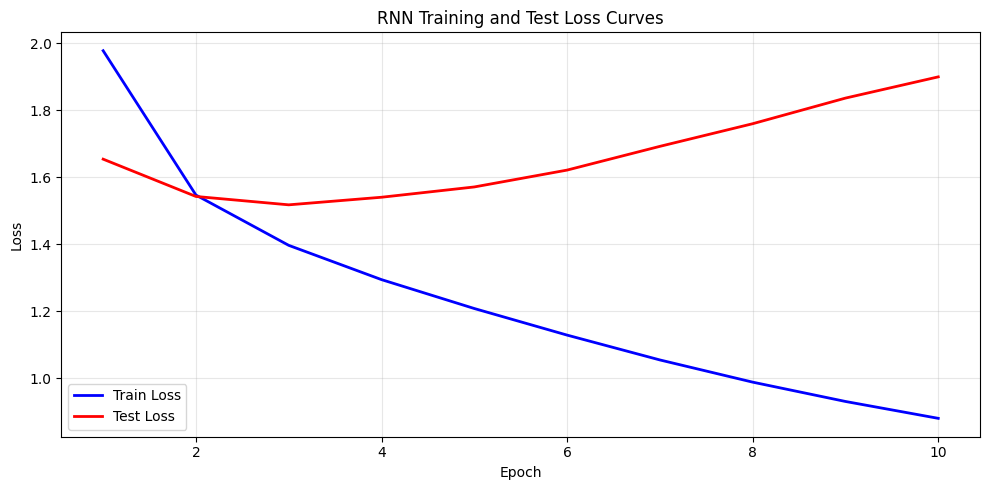

最终 Train Loss: 0.8800
最终 Test Loss:  1.8991


In [14]:
model = RNNTextModel(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 10
train_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    test_loss = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{epochs}')
        print(f'  Train Loss: {train_loss:.4f}')
        print(f'  Test Loss:  {test_loss:.4f}')
        print(f'  Perplexity: {np.exp(test_loss):.2f}')
        print('---')

plot_loss(epochs, train_losses, test_losses)

In [15]:
prefix = 'the time traveller'
print(f'生成前缀: "{prefix}"')
print()

print('temperature=0.5 (更保守):')
gen1 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.5)
print(gen1)
print()

print('temperature=0.8 (中等随机):')
gen2 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.8)
print(gen2)
print()

print('temperature=1.2 (更随机):')
gen3 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=1.2)
print(gen3)

生成前缀: "the time traveller"

temperature=0.5 (更保守):
the time travelleraped away. the time traveller s forttions clad in the absence of green the parent body. as it were nother man of conditions and the eddies would stood beail by mand a little one was gone, and so that 

temperature=0.8 (中等随机):
the time travellerd to generations in particular which was

rest to the explosion to fear the hall; at little weena she hail grindles or pain at the fierce from my apprection. 



 what i among the sphinx, other, i no 

temperature=1.2 (更随机):
the time travellerus were following through the

examtal that explained the furious





 may. it during reilf, to do for; intementto her matches. i had

hattereveral tince. there meraca shident, turned to a ground my 


###### 2. 调整隐层维度

In [18]:
model = RNNTextModel(vocab_size, embed_dim=64, hidden_size=128, num_layers=1).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {total_params:,}')

RNNTextModel(
  (embed): Embedding(40, 64)
  (drop): Dropout(p=0.3, inplace=False)
  (rnn): RNN(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=40, bias=True)
)
总参数量: 32,552


Epoch  1/20
  Train Loss: 1.9725
  Test Loss:  1.6431
  Perplexity: 5.17
---
Epoch  5/20
  Train Loss: 1.2116
  Test Loss:  1.5643
  Perplexity: 4.78
---
Epoch 10/20
  Train Loss: 0.8806
  Test Loss:  1.9020
  Perplexity: 6.70
---
Epoch 15/20
  Train Loss: 0.7265
  Test Loss:  2.1490
  Perplexity: 8.58
---
Epoch 20/20
  Train Loss: 0.6617
  Test Loss:  2.2551
  Perplexity: 9.54
---


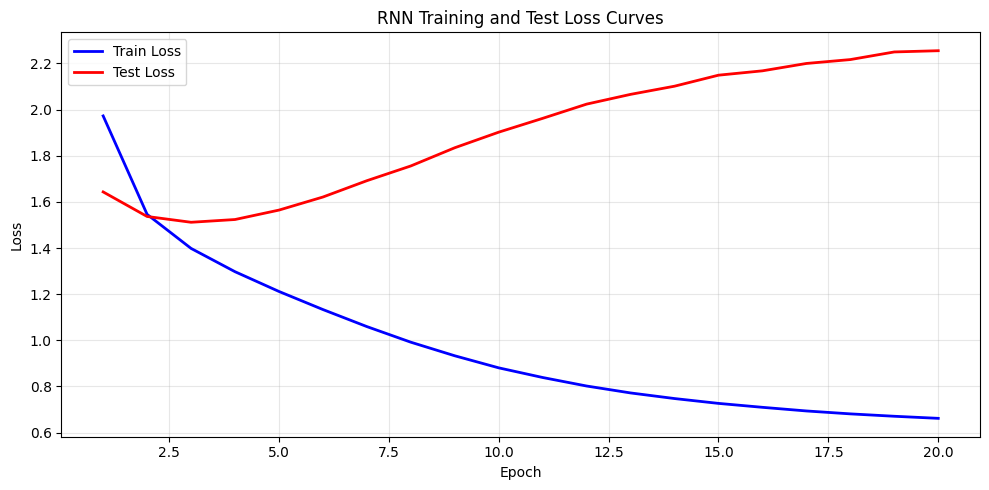

最终 Train Loss: 0.6617
最终 Test Loss:  2.2551


In [21]:
model = RNNTextModel(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 20
train_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    test_loss = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{epochs}')
        print(f'  Train Loss: {train_loss:.4f}')
        print(f'  Test Loss:  {test_loss:.4f}')
        print(f'  Perplexity: {np.exp(test_loss):.2f}')
        print('---')

plot_loss(epochs, train_losses, test_losses)

In [22]:
prefix = 'the time traveller'
print(f'生成前缀: "{prefix}"')
print()

print('temperature=0.5 (更保守):')
gen1 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.5)
print(gen1)
print()

print('temperature=0.8 (中等随机):')
gen2 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.8)
print(gen2)
print()

print('temperature=1.2 (更随机):')
gen3 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=1.2)
print(gen3)

生成前缀: "the time traveller"

temperature=0.5 (更保守):
the time travellery on the great hills for me. and that they had left their little beautiful race the patter and by as the morlocks face tables. i did not see what like the carloved, and even to ling and only to pretty

temperature=0.8 (中等随机):
the time travellery rou has attained my coor.



 then i thought once how to cert it, and when i laughed into my mind.



 i am toling the trees. i hastily swonted till

couranles of again utrating these mean doors was

temperature=1.2 (更随机):
the time travellery at the time

traveller procies of soferdow, and when i began to light it laved, too, how such moment. 



it now, i sthoch. bu in some by i nound it. i have

a minute was three garden, from to pearl


#### 3. 扩展任务（选做）
##### （1）GRU 文本预测模型：
在完成 RNN 文本预测模型的基础上，尝试将循环层由 nn.RNN 替换为 nn.GRU。比较 GRU 与普通 RNN 在训练 Loss、测试 Loss、Perplexity 和生成文本效果上的差异。 

构造GRU

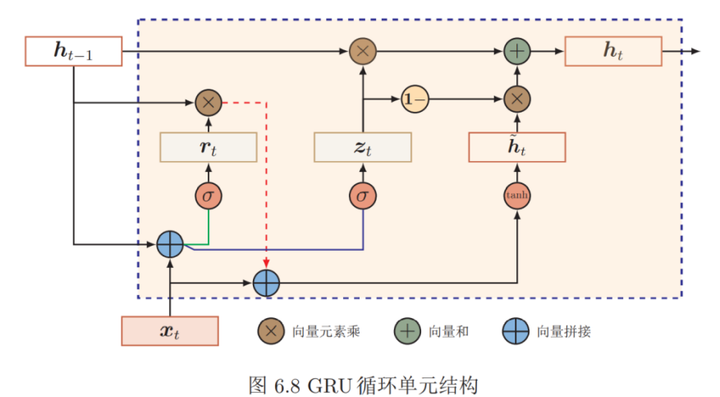

In [55]:
import torch
import torch.nn as nn

class GRUTextModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)   # 用于 fc 层之前
        
        # 使用 nn.GRU 替代 nn.RNN
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0   # 层间 dropout，仅当 num_layers>1 时有效
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len)
        x = self.embed(x)                     # (batch, seq_len, embed_dim)
        out, hidden = self.gru(x, hidden)     # out: (batch, seq_len, hidden_size)
                                              # hidden: (num_layers, batch, hidden_size)
        out = self.dropout(out)               # 可选：对输出序列做 dropout
        logits = self.fc(out)                 # (batch, seq_len, vocab_size)
        return logits, hidden


model = GRUTextModel(vocab_size)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {total_params:,}')

GRUTextModel(
  (embed): Embedding(40, 128)
  (dropout): Dropout(p=0.3, inplace=False)
  (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=40, bias=True)
)
总参数量: 706,600


Epoch  1/5
  Train Loss: 2.0416
  Test Loss:  1.6072
  Perplexity: 4.99
---
Epoch  5/5
  Train Loss: 1.1905
  Test Loss:  1.4755
  Perplexity: 4.37
---


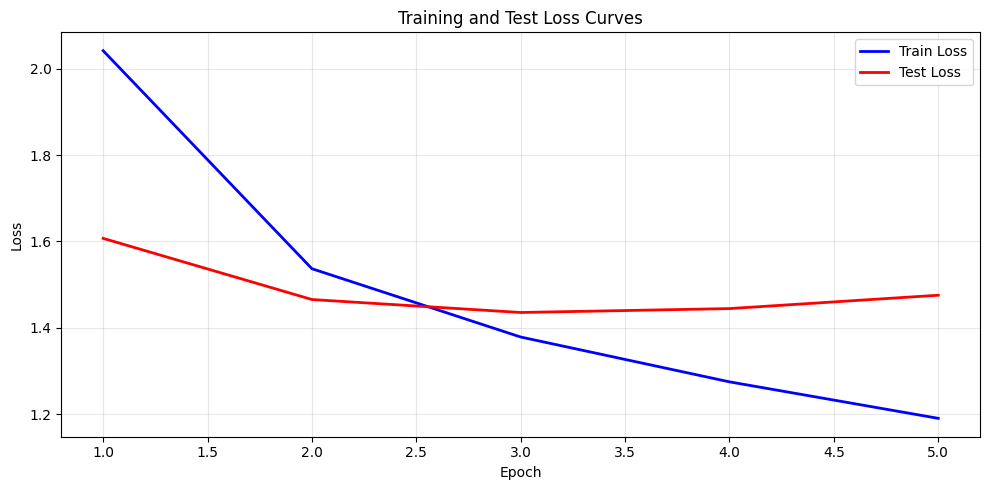

最终 Train Loss: 1.1905
最终 Test Loss:  1.4755


In [66]:
model = GRUTextModel(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 5
train_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    test_loss = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{epochs}')
        print(f'  Train Loss: {train_loss:.4f}')
        print(f'  Test Loss:  {test_loss:.4f}')
        print(f'  Perplexity: {np.exp(test_loss):.2f}')
        print('---')

plot_loss(epochs, train_losses, test_losses)

In [59]:
prefix = 'the time traveller'
print(f'生成前缀: "{prefix}"')
print()

print('temperature=0.5 (更保守):')
gen1 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.5)
print(gen1)
print()

print('temperature=0.8 (中等随机):')
gen2 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.8)
print(gen2)
print()

print('temperature=1.2 (更随机):')
gen3 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=1.2)
print(gen3)

生成前缀: "the time traveller"

temperature=0.5 (更保守):
the time traveller in the sphinx and the little people were seemed to

me and the face of the whole his back to the same was the bushes and flowers that i was somehow, and the great

hundred to the stars of the gallery

temperature=0.8 (中等随机):
the time travellery was a lemp framelient filby should leave

the head of was in my

pathed out of a persucation and the paradox saw a protected by the warw, and distinct; the whole of

the palace of green porcelain an

temperature=1.2 (更随机):
the time travellery cases of pothing orward,

and with as the dimensionity was selblessory came over to q-ace.

bodf; faintal. chilbridened interdusting coming match of bronze; nothing night and vast, i saw,

possip of


句子起码能看了，还是有部分过拟合现象

##### （2）LSTM 文本预测模型：
尝试将循环层替换为 nn.LSTM，构建 LSTM 文本预测模型。观察 LSTM 对较长文本依赖关系的建模能力，并与 RNN、GRU 的结果进行 对比。 

构造LSTM

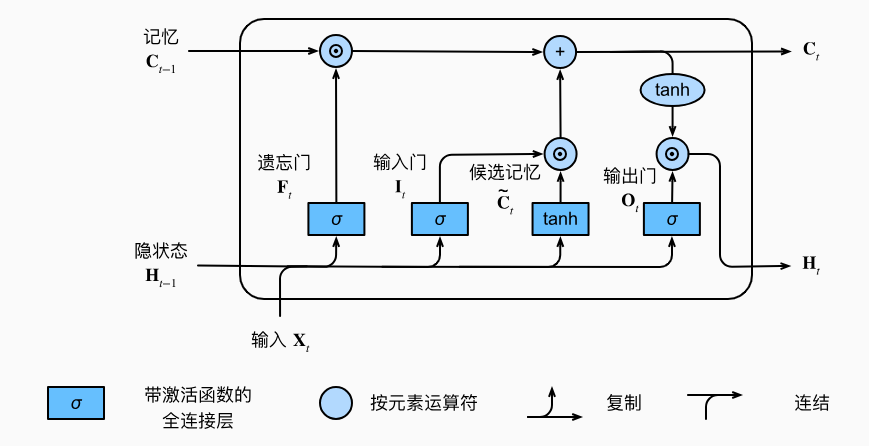

In [60]:
import torch
import torch.nn as nn

class LSTMTextModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.dropout = nn.Dropout(dropout)   # 用于 fc 层之前
        
        # 使用 nn.LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0   # 层间 dropout
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len)
        x = self.embed(x)                     # (batch, seq_len, embed_dim)
        out, (h_n, c_n) = self.lstm(x, hidden)   # out: (batch, seq_len, hidden_size)
                                                  # h_n: (num_layers, batch, hidden_size)
                                                  # c_n: (num_layers, batch, hidden_size)
        out = self.dropout(out)               # 对输出序列做 dropout
        logits = self.fc(out)                 # (batch, seq_len, vocab_size)
        # 返回 logits 和隐藏状态元组 (h_n, c_n)，以便后续用作初始状态
        return logits, (h_n, c_n)


model = LSTMTextModel(vocab_size) 
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {total_params:,}')

LSTMTextModel(
  (embed): Embedding(40, 128)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=40, bias=True)
)
总参数量: 937,000


Epoch  1/5
  Train Loss: 2.2175
  Test Loss:  1.7403
  Perplexity: 5.70
---
Epoch  5/5
  Train Loss: 1.2865
  Test Loss:  1.4556
  Perplexity: 4.29
---


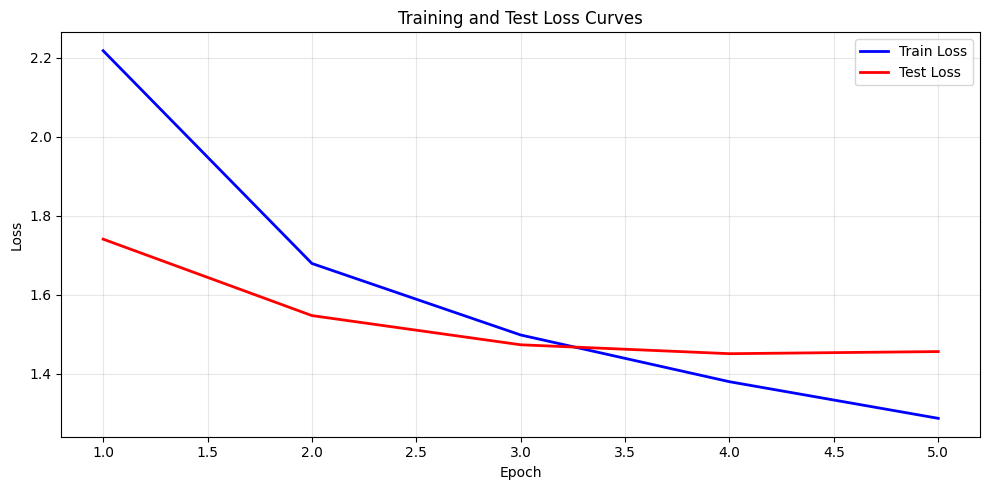

最终 Train Loss: 1.2865
最终 Test Loss:  1.4556


In [65]:
model = LSTMTextModel(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 5
train_losses = []
test_losses = []

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    test_loss = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{epochs}')
        print(f'  Train Loss: {train_loss:.4f}')
        print(f'  Test Loss:  {test_loss:.4f}')
        print(f'  Perplexity: {np.exp(test_loss):.2f}')
        print('---')

plot_loss(epochs, train_losses, test_losses)

In [62]:
prefix = 'the time traveller'
print(f'生成前缀: "{prefix}"')
print()

print('temperature=0.5 (更保守):')
gen1 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.5)
print(gen1)
print()

print('temperature=0.8 (中等随机):')
gen2 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=0.8)
print(gen2)
print()

print('temperature=1.2 (更随机):')
gen3 = generate_text(model, prefix, char_to_idx, idx_to_char, temperature=1.2)
print(gen3)

生成前缀: "the time traveller"

temperature=0.5 (更保守):
the time travellered down the sun was and to the sphinx and the thing that i had to slow down the shaft, and i tried to complete one of a scarte who had still i had seen and the little day of the asting of the little d

temperature=0.8 (中等随机):
the time travellered should like the buildings. i was flare carry

that long in the new upon the woods the same blendow up an of branging by the world had startled for a shirible of the morlocks before the flicker. i c

temperature=1.2 (更随机):
the time travellery. then, we time sorabacy.



 i thought the praict, at youn tabivated, and one went on day now, by order cambering. i have no doubt the interfimetness. what us in the gettentation, said, a vain i sho


感觉效果还可以

#### 4. 阶段二结果分析

RNN 文本预测部分需要讨论输入序列长度、隐藏状态维度、训练轮数对文本生成效果的影响。 

| 实验配置 | 核心参数/结构 | Perplexity |
|----------|---------------|--------------| 
| RNN(基础版) | sequence=80 embedding(128*256) -> dropout(0,3) -> RNN(2) epoch = 20 | 9.39 |
| RNN(调参1) | sequence=80 embedding(128*256) -> dropout(0,3) -> RNN(2) epoch = 10 | 6.68 |
| RNN(调参2) | sequence=80 embedding(64*128) -> dropout(0,3) -> RNN(1) epoch = 20 | 9.54 |
| RNN(调参3)| sequence=100 embedding(128*256) -> dropout(0,3) -> RNN(2) epoch = 20 | 10.63 |
| GRU | sequence=80 embedding(128*256) -> dropout(0,3) -> GRU(2) epoch = 5 | 4.38 |
| LSTM | sequence=80 embedding(128*256) -> dropout(0,3) -> LSTM(2) epoch = 5 | 4.29 |


参数量减少和训练轮数减少都能提升文本生成的质量，但输入序列长度增加反而加剧了过拟合。

实际上这里几乎每个模型都在训练集上产生了过拟合，基本在第二个epoch后就开始。对于RNN的训练引入早停机制尤为重要。

GRU 和 LSTM 的效果显然比单纯的 RNN 要好很多，引入门控单元可以让记忆变的更加高效。



## 五、实验结果与分析

本实验主要包含两部分内容：第一部分是基于 CNN 与 Center Loss 的特征表征学习，第二部分是基于 RNN 的文本序列预测。整体来看，实验结果较好地验证了不同模型结构与参数设置对分类性能、特征空间分布以及文本生成质量的影响。

### 1. 图像特征表征实验结果与分析

在 MNIST 分类任务中，基础 LeNet 模型最终测试准确率达到 **99.23%**，加入 Batch Normalization 的 LeNetPlus 最终测试准确率为 **99.08%**。虽然两者最终精度接近，但从训练过程来看，Batch Normalization 明显提升了模型的收敛速度。例如在第 1 个 epoch 时，LeNet 的训练损失为 **0.2104**、训练准确率为 **93.47%**，而 LeNetPlus 的训练损失已经下降到 **0.0499**、训练准确率达到 **98.47%**。这说明 BN 能够有效缓解训练过程中的分布波动，使网络更快进入稳定收敛状态。之所以最终测试精度没有明显拉开差距，主要是因为 MNIST 本身任务难度较低，基础 LeNet 已经能够达到较高的识别上限，因此 BN 的优势更多体现在优化过程而不是最终精度上。

在引入 Center Loss 后，LeNetPlus + CenterLoss 模型经过 20 个 epoch 训练后，最终测试准确率为 **98.77%**。与普通分类模型相比，其精度略有下降，但特征空间的可分性明显增强。结合 2D 特征散点图可以观察到：在训练初期，不同类别样本在特征空间中分布较为混杂；随着训练进行，同一类别样本逐渐向各自中心靠拢，类内方差不断减小，不同类别之间的边界也变得更加清晰。这表明 Center Loss 不仅关注“分对类别”，还显式约束了“同类样本要靠近”，因此能够有效提升特征的判别性。精度下降的原因在于该模型最后增加了 **2 维瓶颈层**，这虽然有利于可视化，但会压缩特征表达能力，使分类任务受到一定限制。

进一步比较“直接输出 2D 特征”与“高维特征后再用 t-SNE 降维”的结果可以发现，前者测试准确率仅为 **66.25%**，后者则达到 **98.65%**。说明如果直接强行把判别特征压缩到二维，模型表达能力会严重受限；而先在高维空间中学习充分的判别特征，再利用 t-SNE 做后处理降维，可在保留分类能力的同时得到更清晰的可视化结果。因此，从实验效果看，**二维特征更适合用于展示，而高维特征更适合用于真正的分类任务**。

在 Center Loss 权重 λ 的扫描实验中，也能明显看到聚类效果与分类性能之间的平衡关系。当 **λ=0** 时，测试准确率为 **77.35%**，类内半径较大，但类间距离和全局扩张程度较好，属于相对平衡的状态；当 λ 增大到 **0.01** 及以上时，类内半径继续减小，但最小类间距和全局扩张也开始同步缩小，模型逐渐出现“过坍缩”现象。特别是 λ=0.3 时，测试准确率下降到 **60.65%**。这说明 Center Loss 权重并不是越大越好：若过分强调“类内紧凑”，会使不同类别的特征空间一起被压缩，反而损害分类性能。因此，本实验表明 **Center Loss 的关键在于平衡类内紧凑与类间分离，而不是单纯缩小类内距离**。

### 2. 文本序列预测实验结果与分析

在文本预测实验中，基础 RNN 模型使用 `sequence length=80`、`embedding=128`、`hidden size=256`、`num_layers=2` 的设置训练 20 个 epoch。结果显示，训练损失持续下降，从 **1.9618** 降到 **0.6037**，但测试损失却在前期下降后明显回升，最终达到 **2.3635**，对应困惑度 **10.63**。其中第 5 个 epoch 时测试损失仅为 **1.5972**，困惑度为 **4.94**，之后随着训练继续进行，测试性能反而恶化。这说明模型已经出现了较明显的**过拟合**：它越来越擅长记忆训练文本，却不能很好地泛化到测试集。

将训练轮数从 20 轮减少到 10 轮后，模型最终测试损失变为 **1.8991**，困惑度为 **6.68**，明显优于训练 20 轮时的结果。从生成文本样例来看，10 轮模型输出的句子结构也更加自然，可读性更强。这说明在当前数据量和模型规模下，过长时间训练会导致模型过度记忆训练样本，因此适当减少训练轮数或加入早停机制能够有效改善生成效果。换言之，**对字符级 RNN 来说，训练轮数并非越多越好，关键在于控制泛化误差**。

关于隐藏状态维度与模型规模，实验中还构造了更小的 RNN 结构（`embedding=64`、`hidden size=128`、`num_layers=1`），其参数量由原模型的 **245,800** 显著减少到 **32,552**。这说明减小隐藏维度可以有效降低模型复杂度，从而减轻过拟合风险。不过从当前 notebook 保留的结果来看，这部分缺少一组完全对应的训练对比输出，因此更适合做定性分析：**隐藏维度减小有助于压缩参数量、提升训练稳定性，但若过小也会削弱模型对长距离依赖和复杂语义模式的表达能力**。

从文本生成结果来看，温度参数对输出风格影响显著。当 `temperature=0.5` 时，生成文本更保守，单词和句法更稳定，但重复现象较明显；当 `temperature=0.8` 时，生成内容更丰富，局部句子更接近自然语言，但也开始出现拼写错误；当 `temperature=1.2` 时，随机性明显增强，虽然多样性更高，但语义连贯性明显下降，容易出现无意义字符组合。这说明温度参数本质上控制了“稳定性”和“多样性”之间的权衡。

在扩展实验中，GRU 和 LSTM 的表现明显优于普通 RNN。GRU 在仅训练 **5 个 epoch** 的情况下，测试损失达到 **1.4755**，困惑度为 **4.37**；LSTM 的测试损失进一步降低到 **1.4556**，困惑度为 **4.29**，为所有模型中最好。生成文本也显示，GRU 和 LSTM 输出的单词完整性、句子连续性以及上下文合理性都优于普通 RNN。这是因为门控结构能够更有效地保留长期依赖信息，缓解普通 RNN 容易出现的梯度消失和记忆能力不足问题。因此，本实验进一步说明：**在序列建模任务中，带门控机制的循环网络通常比基础 RNN 具有更好的稳定性与生成质量**。

### 3. 综合分析

综合两个阶段的实验结果可以看出：在图像任务中，模型性能不仅体现在最终准确率上，还体现在特征空间是否具有良好的“类内紧凑、类间分离”性质；而在文本任务中，模型优劣不仅体现在训练损失是否下降，更要关注测试集困惑度和实际生成文本的可读性。前者说明了“表征学习质量”的重要性，后者说明了“泛化能力”和“生成质量”同样关键。

总体而言，本次实验验证了以下几点：
（1）**Batch Normalization** 能够明显加速 CNN 训练收敛，但在简单任务上不一定显著提高最终精度；
（2）**Center Loss** 可以有效改善特征聚类效果，但若权重过大容易造成特征空间过坍缩，从而损害分类性能；
（3）基础 **RNN** 在文本生成任务中容易过拟合，适当减少训练轮数或采用早停策略十分必要；
（4）**GRU 与 LSTM** 由于引入门控机制，在困惑度和生成质量上都明显优于普通 RNN，是更适合文本序列建模的结构。

## 六、问题与解决过程
### 1. 过拟合问题
在本次实验中，模型训练并不是一直“训练得越久越好”，而是出现了较明显的训练集指标与验证集（测试集）指标之间的竞争现象。其中最典型的问题出现在 RNN 文本预测部分：随着训练轮数增加，训练 loss 持续下降，说明模型对训练集拟合越来越充分；但与此同时，验证/测试 loss 在下降到一定程度后反而开始上升，Perplexity 也随之变大，说明模型虽然越来越会“记住训练数据”，却没有同步提升对未见数据的泛化能力，出现了过拟合现象。

以基础 RNN 为例，训练初期模型的训练 loss 和测试 loss 都在下降，说明网络确实学到了字符序列中的统计规律；但训练到后期后，训练 loss 继续下降，而测试 loss 不再下降，甚至明显回升。这说明模型开始过度记忆训练文本中的局部模式，而不是学习更具泛化性的语言规律。生成结果也印证了这一点：虽然部分句子表面上更流畅，但整体语义连贯性没有同步提高，甚至会出现重复、拼写异常和上下文跳跃等问题。

针对这一现象，我在后续实验中减少了训练轮数，将训练 epoch 从 20 轮缩短到 10 轮，结果发现测试 loss 和困惑度都有明显改善，生成文本也更加自然。因此可以看出，在该任务中，控制训练轮数、避免模型过拟合，比单纯追求更低的训练 loss 更重要。

### 2. 瓶颈层限制
第二个较为明显的问题出现在特征表征学习部分。加入 Batch Normalization 后，模型前期收敛速度明显加快，训练更加稳定；但在引入 Center Loss 并将特征维度压缩到 2 维后，训练难度增大，模型精度没有继续提升，反而受到一定影响。刚开始我认为是模型实现有问题，但在对比不同实验结果后发现，主要原因并不是程序错误，而是二维瓶颈层本身限制了特征表达能力。也就是说，二维特征虽然便于可视化，但会牺牲部分分类性能。因此在分析结果时，我将这一现象理解为“可视化需求”和“分类性能需求”之间的权衡，而不是简单地把精度下降归因于模型训练失败。

### 3. Center Loss 的不稳定性
第三个问题是 Center Loss 权重设置带来的不稳定性。在实验初期，我倾向于认为只要增大 Center Loss 权重，就能让同类样本聚得更紧，从而获得更好的结果；但实际训练中发现，当权重过大时，虽然类内距离减小了，但类间距离也被一并压缩，导致不同类别之间的边界变差，最终分类性能反而下降。这个问题说明，Center Loss 的作用不是单纯追求“越紧越好”，而是要在“类内紧凑”和“类间可分”之间取得平衡。为了解决这个问题，我对不同 λ 进行了扫描比较，最终认识到合理的参数选择应结合精度和可视化效果共同判断，而不能只看某一个指标。


## 七、思考题
### 1. 特征空间意义：为什么将 Embedding 降维到 2D 可视化能帮助我们理解模型的好坏？如果两个数字类别的簇在 2D 空间中严重重叠，说明模型存在什么问题？

将 Embedding 或中间特征压到 2D 后可视化，能把“模型到底把不同类别分开了没有”直观看出来。理想情况下，同一类样本会聚成紧凑的簇，不同类之间有明显间隔，这说明特征具有较好的“类内紧凑、类间分离”性质。如果两个数字类别在 2D 空间里严重重叠，通常说明模型学到的特征判别性不够，这两类在特征空间中难分，分类器只能靠很勉强的边界去分。补一句，如果这个 2D 只是后处理降维结果，也可能有投影损失；但如果 2D 本身就是模型直接学习出来的特征空间，那重叠就更能说明问题。

### 2. BN 的位置：Batch Normalization 应该放在激活函数（如 ReLU）之前还是之后？ 在 CPU 环境下，BN 对训练速度的主要贡献体现在哪里？在测试/推理阶段，Batch Normalization 的均值和方差是如何确定的？它与训练阶段有何不同？

Batch Normalization 常见放法是 Linear/Conv -> BN -> ReLU，也就是放在激活函数之前。这么做是因为 BN 先把线性输出标准化，再交给非线性激活，通常更稳定。在 CPU 环境下，BN 对“训练速度”的主要帮助通常不是单步计算更快，反而每步可能还多一点开销；它真正提升的是“收敛速度”，也就是让训练更稳定、允许更大学习率、减少梯度震荡、用更少 epoch 达到较好效果。测试/推理阶段，BN 不再用当前 batch 的均值和方差，而是使用训练时累计得到的 running_mean 和 running_var。所以训练阶段是“按当前小批量统计并更新滑动平均”，推理阶段是“固定使用历史统计量”，输出会更稳定、也不依赖当前 batch。

### 3. 文本序列构造：在文本预测任务中，为什么目标序列要比输入序列整体向后移动 一个字符？这种构造方式对应的学习目标是什么？

目标序列整体向后移动一个字符，是因为任务本质上是“用前面的字符预测下一个字符”。比如输入是 time，目标就是 ime 这种错开一位的形式。它对应的学习目标是让模型学习条件概率 $P(x_{t+1} | x_1, x_2, ..., x_t)$，也就是看到当前位置之前的上下文后，预测下一时刻最可能出现什么字符。这正是字符级语言模型的基本训练方式。

### 4. RNN 隐藏状态：RNN 中的隐藏状态 $h _ { t }$ 有什么作用？为什么说它可以保存前面 时间步的信息？
   
RNN 的隐藏状态 $h_t$ 可以理解成“到当前时刻为止，模型对前文信息的压缩记忆”。它在每个时间步都会更新，满足类似 $h_t = f(x_t, h_{t-1})$。因为 $h_t$ 同时依赖当前输入 $x_t$ 和上一时刻状态 $h_{t-1}$，所以前面时间步的信息会一级一级传下来。也正因为这样，RNN 才能处理序列，而不是把每个字符当成彼此独立的输入。

### 5. 长期依赖问题：普通 RNN 在处理较长文本序列时，为什么可能出现梯度消失或梯度爆炸问题？这会对文本预测效果造成什么影响？
   
普通 RNN 在长序列上容易出现梯度消失或梯度爆炸，是因为反向传播要跨很多时间步连续相乘。如果这些梯度连乘后越来越小，就会梯度消失；越来越大，就会梯度爆炸。再加上 tanh、sigmoid 这类激活函数容易饱和，这个问题会更明显。梯度消失会让模型学不到远距离依赖，只能记住最近几个字符；梯度爆炸会让训练不稳定，loss 抖动甚至发散。反映到文本预测上，就是模型更容易只会短期模仿，生成文本重复、上下文衔接差，对长距离语义关系把握不好。这也是为什么很多场景会用 GRU/LSTM、梯度裁剪等方法来改进。

## 八、实验小结
在本次实验中，首先，本次实验验证了 BatchNormalization 对于收敛速度的加速，BatchNorm 通过对该批次的数据按通道划分然后归一化，既解决了数据的膨胀或收缩等问题，也保留了数据间的分布特征。BN 第一次广泛使用源于 ResNet ，其中 Conv->BN->Act 的结构已贯彻现代的一切神经网络，本次实验单独讨论了 BN 的作用，加深了我对 BN 的印象，也间接证明 Conv->BN->Act 的强大。

其次，通过维护一个 CenterLoss 来观察特征空间之间的分离是很有意思的环节，但是为了在二维坐标平面显示，会给特征头引入一个瓶颈层，直接导致最后输出的分类结果存在数据损失。

本次实验也是我第一次接触 t-SNE 降维技术。t-SNE 是一种非线性降维算法，其核心思想是：高维空间中相似的点，在低维空间中也应该相似；高维空间中相距很远的点，在低维空间中也应该相距很远。用高斯分布来记录高维空间的概率，再在低维空间用t分布进行迭代，使其满足高斯分布，即最小化高维分布和低维分布间的KL散度。

本次实验，我学会了如何在oytorch里构建RNN、GRU、LSTM等一众类RNN模型，但在文本预测和生成问题上，这些模型的效果并不好，十分容易发生过拟合，而且调参之后结果仍然很差。